In [1]:
import pandas as pd
import numpy as np

from glob import glob
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from PIL import Image

plt.style.use('ggplot')

In [2]:
annot = pd.read_parquet('data_sources/train-val_images/annot.parquet')
imgs = pd.read_parquet('data_sources/train-val_images/img.parquet')
img_fns = glob('data_sources/train-val_images/train_images/*')

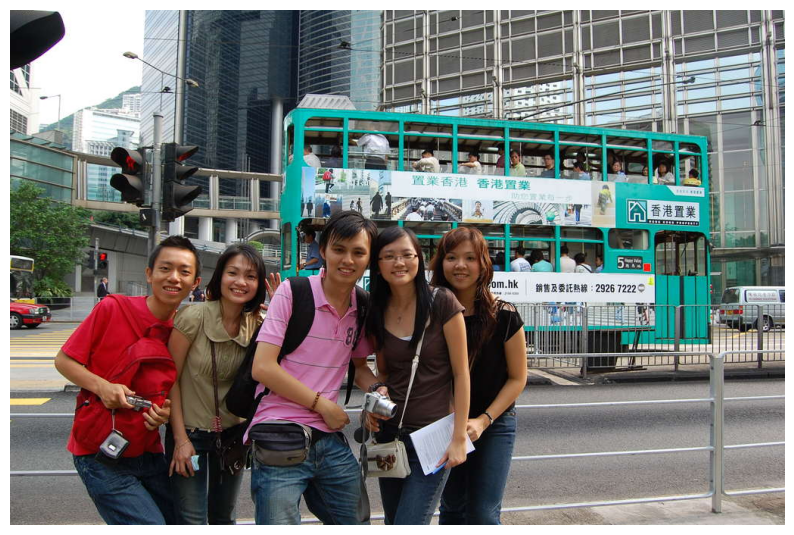

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(plt.imread(img_fns[0]))
ax.axis('off')
plt.show()

In [4]:
image_id = img_fns[0].split('/')[-1].split('.')[0]
annot.query('image_id == @image_id')

,id,image_id,bbox,utf8_string,points,area


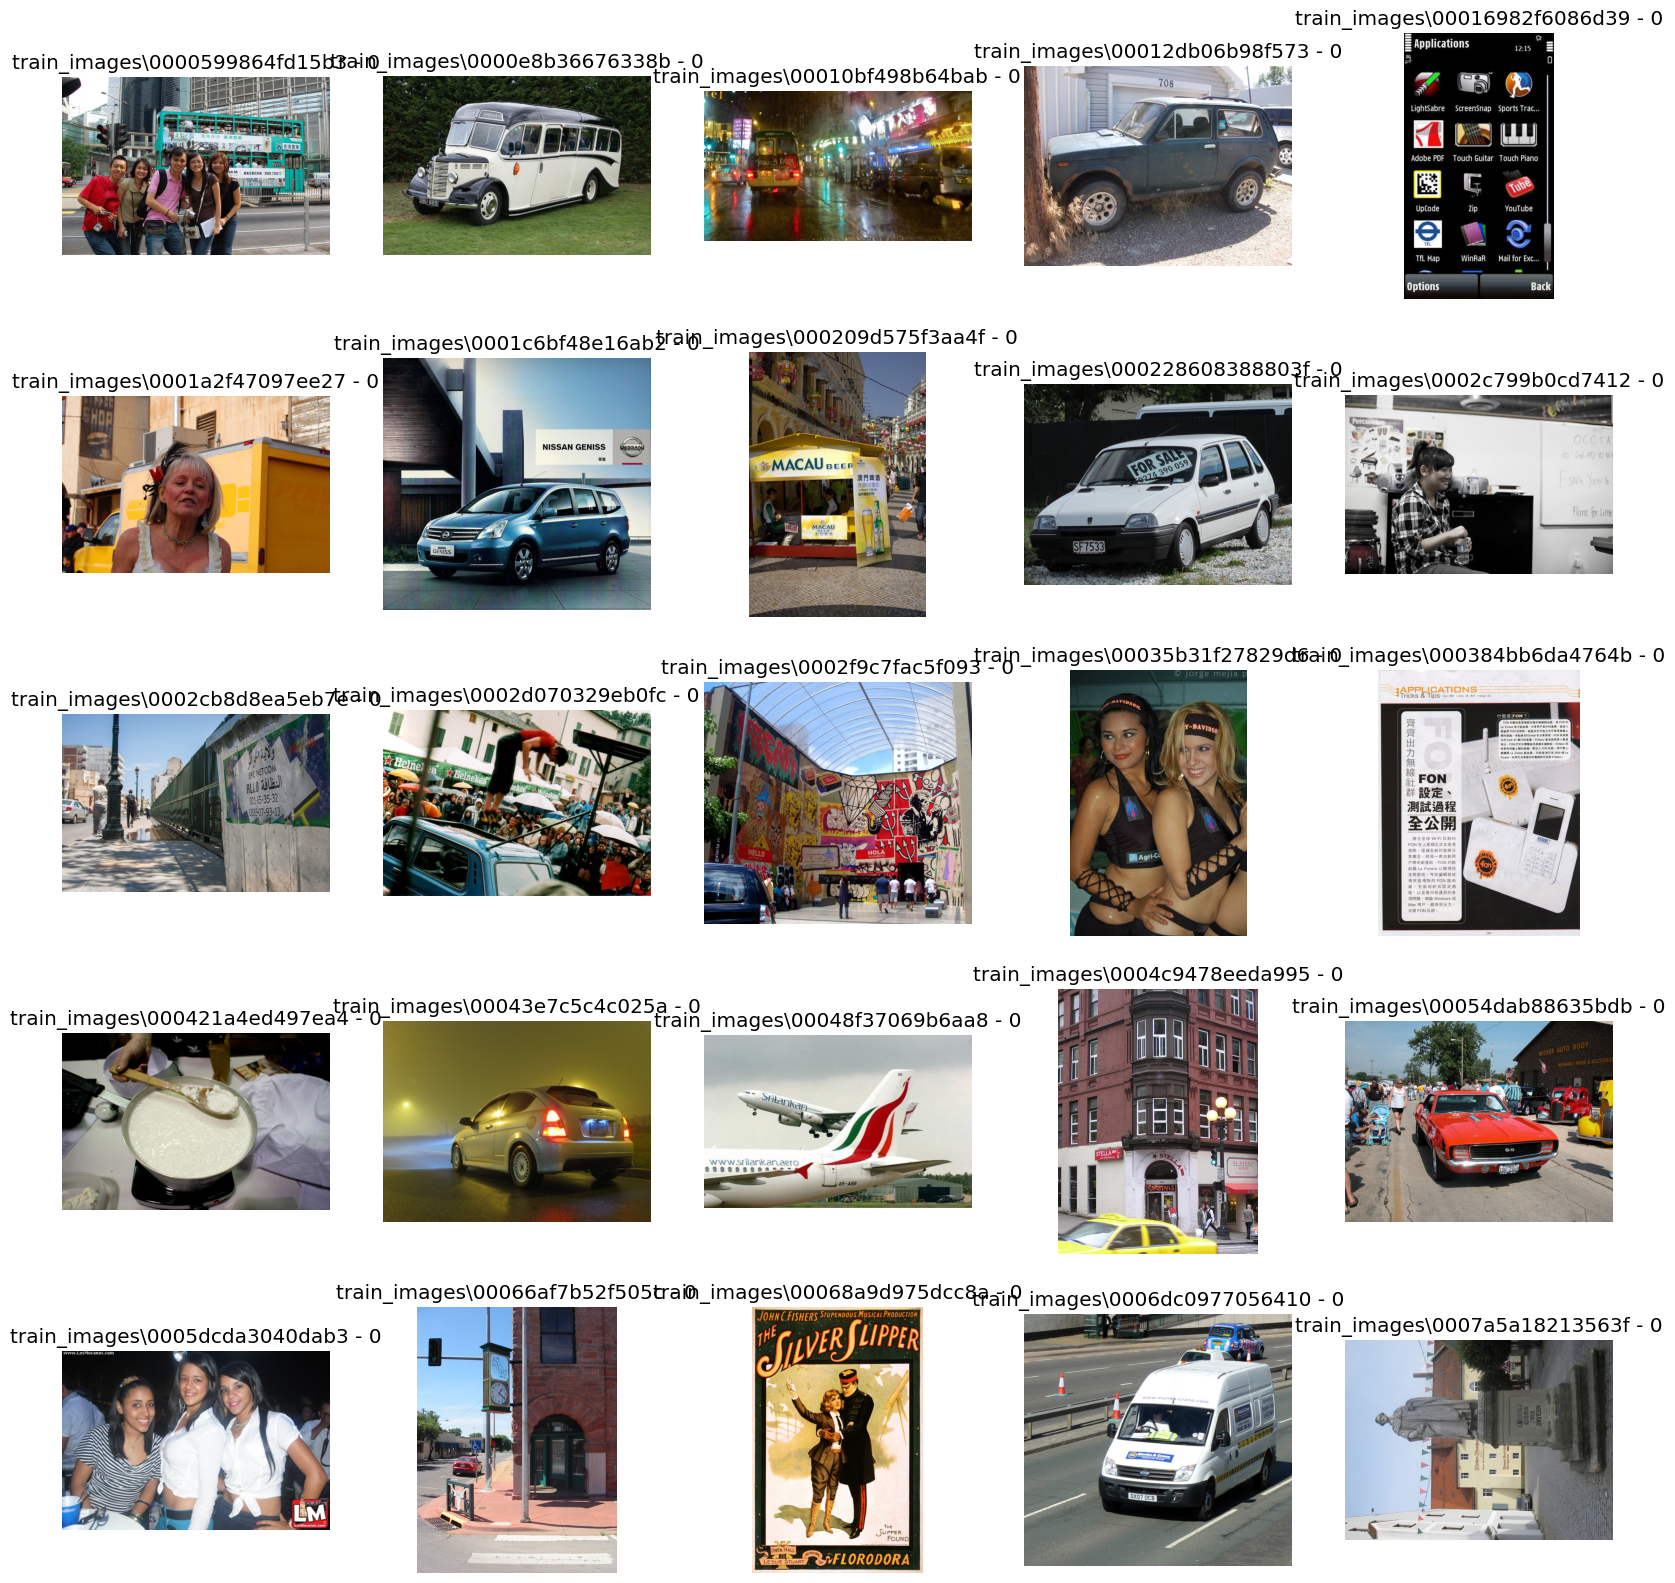

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(20, 20))
axs = axs.flatten()
for i in range(25):
    axs[i].imshow(plt.imread(img_fns[i]))
    axs[i].axis('off')
    image_id = img_fns[i].split('/')[-1].rstrip('.jpg')
    n_annot = len(annot.query('image_id == @image_id'))
    axs[i].set_title(f'{image_id} - {n_annot}')
plt.show()

In [7]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


In [ ]:
import easyocr

reader = easyocr.Reader(['en'], gpu=False)  # use CPU when no GPU is available

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [10]:
results = reader.readtext(img_fns[11])

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [11]:
pd.DataFrame(results, columns=['bbox','text','conf'])

,bbox,text,conf
0,"[[163, 211], [211, 211], [211, 249], [163, 249]]",en,0.787766
1,"[[43.217272924571674, 165.05127422674474], [17...",Heinel,0.549905
2,"[[270.32140589354253, 216.0462630228603], [413...",Helneken |,0.404501
3,"[[484.052175279236, 276.11391864486745], [556....",Meken,0.164014
4,"[[588.1675694221406, 297.0875762840607], [682....",Feheken,0.035622


AttributeError: module 'easyocr' has no attribute 'tools'

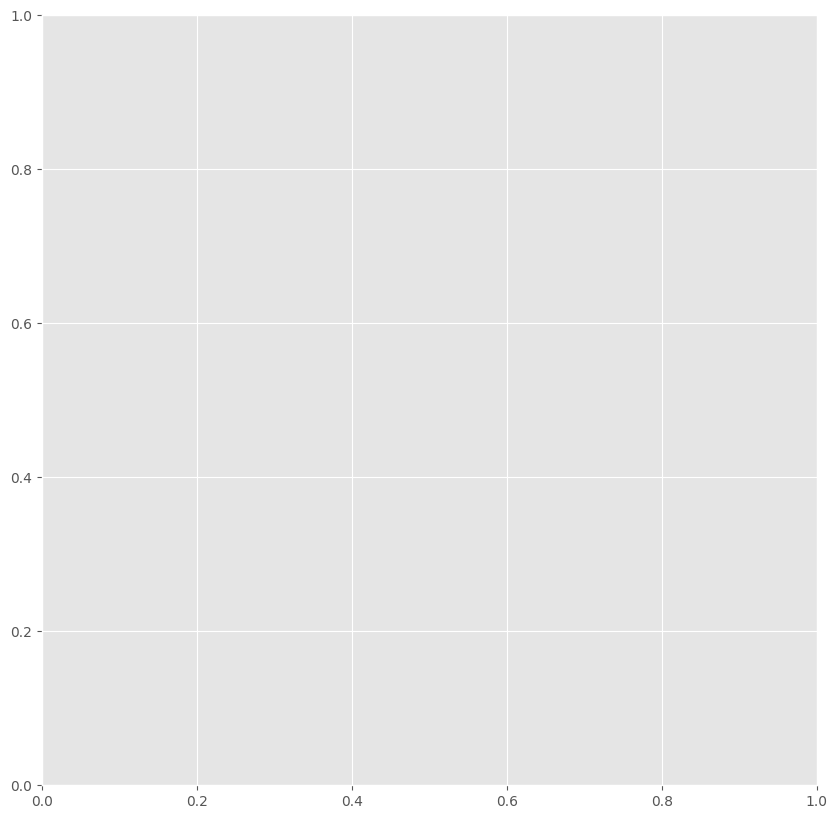

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
image = plt.imread(img_fns[11])
ax.imshow(image)
for bbox, text, conf in results:
    bbox = np.array(bbox, dtype=np.int32)
    patch = plt.Polygon(bbox, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(patch)
    ax.text(bbox[0, 0], bbox[0, 1] - 5, f'{text} ({conf:.2f})', color='yellow', fontsize=8, backgroundcolor='black')
ax.set_title('EasyOCR Result Example')
ax.axis('off')
plt.show()